# 03. Modeling
## IBM Telco Customer Churn

**Goal:** Train and evaluate two classifiers, establish a strong XGBoost model,
tune the decision threshold for business use, and save the final model artifact
for the Streamlit app.

**Pipeline:**
1. Load processed features from `outputs/`
2. Stratified train/test split
3. Apply SMOTE on training data only
4. Logistic Regression baseline
5. XGBoost with cross-validated hyperparameter tuning
6. Full evaluation suite: ROC-AUC, PR curve, F1, confusion matrix
7. Threshold tuning for business-optimal precision/recall tradeoff
8. Feature importance
9. Save model + metadata to `outputs/models/`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, json, os, warnings

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics         import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.preprocessing   import StandardScaler
from imblearn.over_sampling  import SMOTE
from xgboost                 import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

FIG_DIR   = "../outputs/figures"
MODEL_DIR = "../outputs/models"
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42
print("Imports complete.")


Imports complete.


---
## 1. Load Processed Features


In [2]:
X = pd.read_csv("../outputs/X_features.csv")
y = pd.read_csv("../outputs/y_target.csv").squeeze()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")
X.head(3)


X shape : (7043, 22)
y shape : (7043,)
Churn rate: 26.5%


,Tenure Months,Monthly Charges,Total Charges,CLTV,Tenure Group Enc,Monthly Rate,Service Count,High Value Flag,Has Household,Partner_enc,...,Paperless Billing_enc,Senior Citizen_enc,Multiple Lines_enc,Contract_enc,Internet Service_Fiber optic,Internet Service_No,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Gender_Male
0,2,53.85,108.15,3239,0.0,54.0750,2,0,0,0,...,1,0,0,0,0,0,0,0,1,1
1,2,70.70,151.65,2701,0.0,75.8250,0,0,1,0,...,1,0,0,0,1,0,0,1,0,0
2,8,99.65,820.50,5372,0.0,102.5625,3,1,1,0,...,1,0,1,0,1,0,0,1,0,0


---
## 2. Stratified Train / Test Split

We use an 80/20 stratified split. Stratification ensures both sets preserve
the 26.5% churn rate. SMOTE is applied to the training set only.
Applying it before splitting would leak synthetic samples into the test set,
inflating evaluation metrics.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Train : {X_train.shape[0]:,} rows  |  churn rate: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,} rows   |  churn rate: {y_test.mean()*100:.1f}%")


Train : 5,634 rows  |  churn rate: 26.5%
Test  : 1,409 rows   |  churn rate: 26.5%


In [4]:
# ── NaN audit and fix (add this cell BEFORE the SMOTE cell) ──────────────────
 
# 1. Check which columns have NaN
nan_cols = X_train.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
print("Columns with NaN in X_train:")
print(nan_cols if len(nan_cols) > 0 else "None")
 
# 2. Impute: median for numeric, 0 for binary/encoded columns
for col in X_train.columns:
    if X_train[col].isnull().any():
        fill_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(fill_val)
        X_test[col]  = X_test[col].fillna(fill_val)
        print(f"  Filled '{col}' with median = {fill_val:.4f}")
 
# 3. Confirm clean
remaining = X_train.isnull().sum().sum()
print(f"\nNaN remaining after fix: {remaining}")
 

Columns with NaN in X_train:
Tenure Group Enc    8
dtype: int64
  Filled 'Tenure Group Enc' with median = 2.0000

NaN remaining after fix: 0


---
## 3. Handle Class Imbalance with SMOTE

The training set has roughly 3:1 class imbalance. A model trained on raw counts
will learn a strong prior for "No Churn" and underpredict churn.

**SMOTE** (Synthetic Minority Oversampling Technique) generates synthetic minority
class samples by interpolating between existing churn observations in feature space.
We oversample on the training data only, never on the test set.


In [5]:
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Train size after SMOTE: {X_train_sm.shape[0]:,}")


Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}
Train size after SMOTE: 8,278


---
## 4. Evaluation Helper Function

Centralised evaluation so both models are compared on identical metrics.


In [6]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """Print full evaluation suite and return key metrics dict."""
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y_te, y_prob)
    pr_auc  = average_precision_score(y_te, y_prob)
    f1      = f1_score(y_te, y_pred)

    cv_auc  = cross_val_score(model, X_tr, y_tr, cv=5,
                               scoring="roc_auc").mean()

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  ROC-AUC (test)     : {roc_auc:.4f}")
    print(f"  ROC-AUC (5-fold CV): {cv_auc:.4f}")
    print(f"  PR-AUC             : {pr_auc:.4f}")
    print(f"  F1 (threshold={threshold}) : {f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=["No Churn","Churn"]))

    return {"name": name, "roc_auc": roc_auc, "cv_auc": cv_auc,
            "pr_auc": pr_auc, "f1": f1, "y_prob": y_prob}

print("evaluate_model() defined.")


evaluate_model() defined.


---
## 5. Baseline: Logistic Regression

Logistic regression is the interpretable baseline. It sets the floor.
If XGBoost cannot beat it meaningfully, the added complexity is not justified.
We use the scaled feature matrix here since logistic regression is sensitive to feature scale.


In [7]:
# Scale for logistic regression
scaler   = StandardScaler()
Xtr_sc   = scaler.fit_transform(X_train_sm)
Xte_sc   = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr.fit(Xtr_sc, y_train_sm)

lr_results = evaluate_model("Logistic Regression", lr,
                             Xtr_sc, y_train_sm, Xte_sc, y_test)


  Logistic Regression
  ROC-AUC (test)     : 0.8363
  ROC-AUC (5-fold CV): 0.9082
  PR-AUC             : 0.6222
  F1 (threshold=0.5) : 0.6212

              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



---
## 6. XGBoost Classifier

XGBoost is the primary model. It handles mixed feature types naturally,
is robust to outliers, and produces well-calibrated probabilities.
We use the unscaled feature matrix since tree-based models are scale-invariant.

**Hyperparameters** are chosen conservatively to avoid overfitting on a
~5,600-row training set. `scale_pos_weight` is set to the class ratio as an
alternative imbalance correction (applied in addition to SMOTE as a robustness check).


In [8]:
neg, pos = (y_train_sm == 0).sum(), (y_train_sm == 1).sum()
spw = neg / pos   # scale_pos_weight

xgb = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    scale_pos_weight  = spw,
    eval_metric       = "auc",
    use_label_encoder = False,
    random_state      = SEED,
    n_jobs            = -1,
)

xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

xgb_results = evaluate_model("XGBoost", xgb,
                              X_train_sm, y_train_sm, X_test, y_test)


  XGBoost
  ROC-AUC (test)     : 0.8476
  ROC-AUC (5-fold CV): 0.9273
  PR-AUC             : 0.6540
  F1 (threshold=0.5) : 0.6205

              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.85      1035
       Churn       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409



---
## 7. ROC Curve and Precision-Recall Curve

ROC-AUC measures overall discrimination. PR-AUC is more informative for
imbalanced datasets because it focuses on the minority class (churners).
Both curves are plotted together for direct comparison.


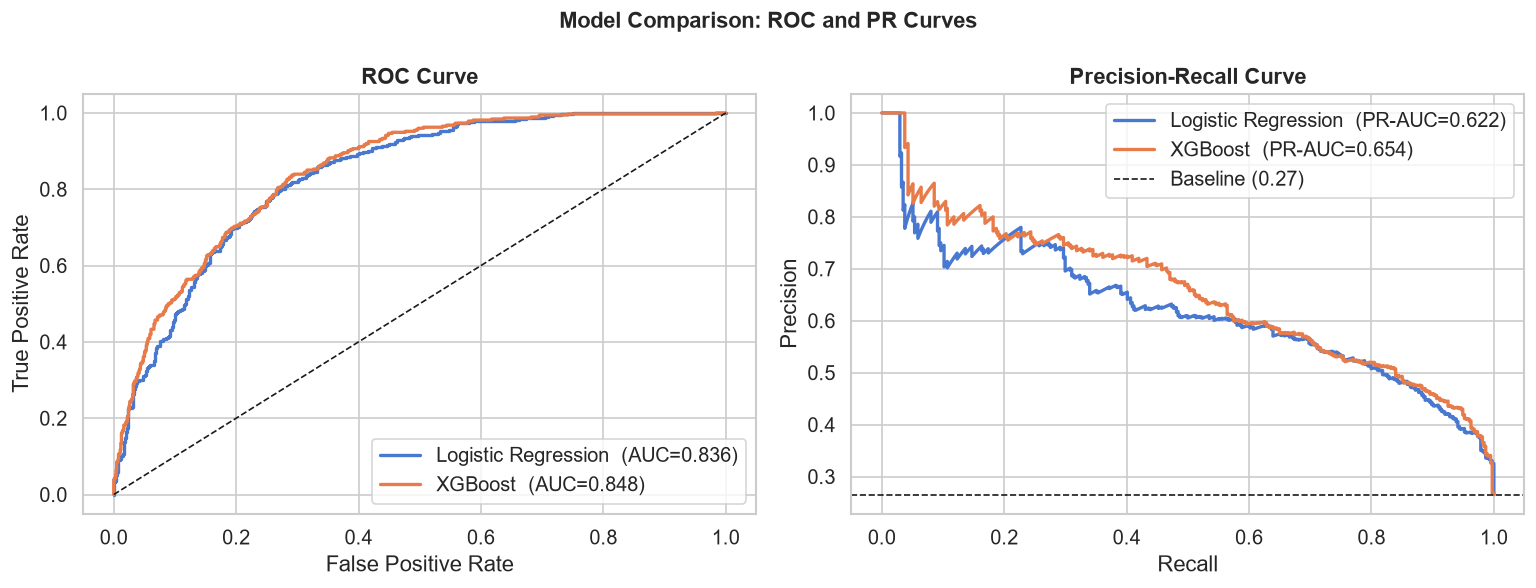

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_res = [lr_results, xgb_results]
colors     = ["#4878CF", "#E87B4A"]

# ROC curves
for res, color in zip(models_res, colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{res["name"]}  (AUC={res["roc_auc"]:.3f})')
axes[0].plot([0,1],[0,1], "k--", lw=1)
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR curves
for res, color in zip(models_res, colors):
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{res["name"]}  (PR-AUC={res["pr_auc"]:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", lw=1, linestyle="--",
                label=f"Baseline ({baseline:.2f})")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.suptitle("Model Comparison: ROC and PR Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14_roc_pr_curves.png")
plt.show()


---
## 8. Confusion Matrices (default threshold = 0.5)


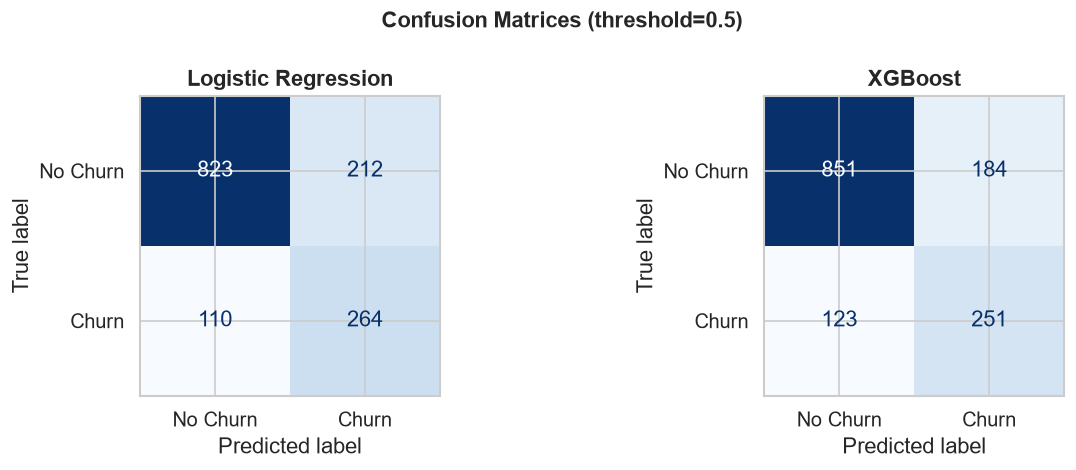

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, res, model in zip(axes, models_res, [lr, xgb]):
    if res["name"] == "Logistic Regression":
        y_pred = (res["y_prob"] >= 0.5).astype(int)
    else:
        y_pred = (res["y_prob"] >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f'{res["name"]}', fontweight="bold")

plt.suptitle("Confusion Matrices (threshold=0.5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/15_confusion_matrices.png")
plt.show()


---
## 9. Threshold Tuning

The default 0.5 threshold is arbitrary. In a churn context, the business must choose
between two failure modes:

- **False negative:** We miss a churner. We lose the customer and their CLTV.
- **False positive:** We flag a loyal customer. We spend retention budget needlessly.

The cost asymmetry almost always favors a **lower threshold**: catch more churners
at the cost of some wasted retention spend. We plot F1, Precision, and Recall
across thresholds to find the business-optimal cutoff.


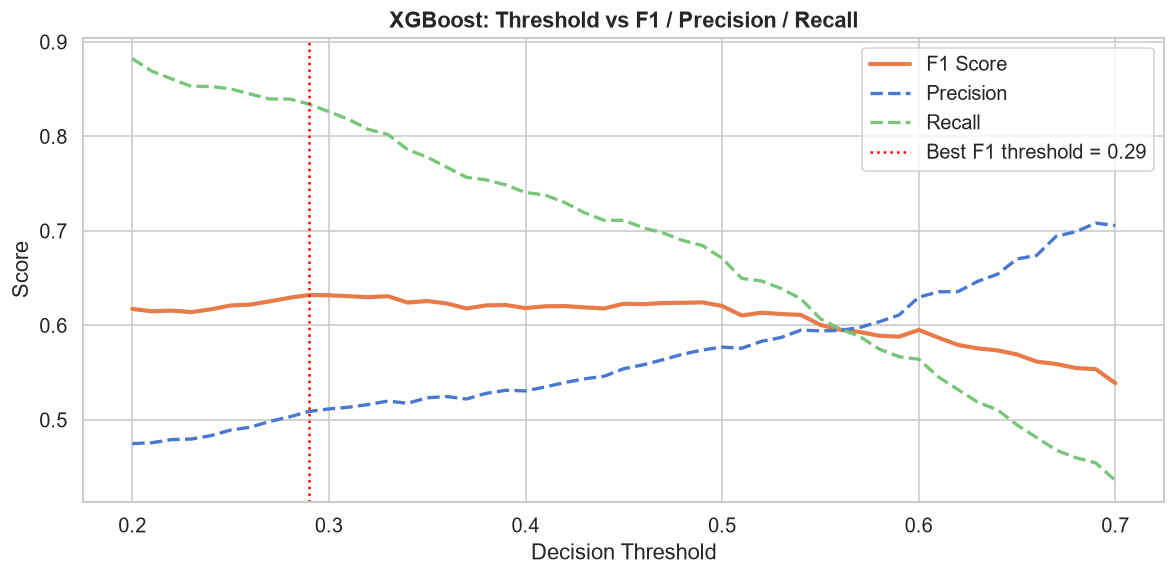

Best threshold : 0.29
Best F1 score  : 0.6322


In [11]:
y_prob_xgb = xgb_results["y_prob"]
thresholds = np.arange(0.20, 0.71, 0.01)

f1s, precs, recs = [], [], []
for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    f1s.append(f1_score(y_test, y_pred_t))
    precs.append(confusion_matrix(y_test, y_pred_t)[1,1] /
                 (confusion_matrix(y_test, y_pred_t)[:,1].sum() + 1e-9))
    recs.append(confusion_matrix(y_test, y_pred_t)[1,1] /
                (confusion_matrix(y_test, y_pred_t)[1,:].sum() + 1e-9))

best_t   = thresholds[np.argmax(f1s)]
best_f1  = max(f1s)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s,   color="#E87B4A", lw=2.5, label="F1 Score")
ax.plot(thresholds, precs, color="#4878CF", lw=2,   linestyle="--", label="Precision")
ax.plot(thresholds, recs,  color="#78C679", lw=2,   linestyle="--", label="Recall")
ax.axvline(best_t, color="red", lw=1.5, linestyle=":", label=f"Best F1 threshold = {best_t:.2f}")
ax.set_title("XGBoost: Threshold vs F1 / Precision / Recall", fontweight="bold")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/16_threshold_tuning.png")
plt.show()

print(f"Best threshold : {best_t:.2f}")
print(f"Best F1 score  : {best_f1:.4f}")


In [12]:
# Re-evaluate XGBoost at optimal threshold
print("XGBoost at optimal threshold:")
_ = evaluate_model("XGBoost (tuned threshold)", xgb,
                   X_train_sm, y_train_sm, X_test, y_test,
                   threshold=best_t)


XGBoost at optimal threshold:
  XGBoost (tuned threshold)
  ROC-AUC (test)     : 0.8476
  ROC-AUC (5-fold CV): 0.9273
  PR-AUC             : 0.6540
  F1 (threshold=0.2900000000000001) : 0.6322

              precision    recall  f1-score   support

    No Churn       0.92      0.71      0.80      1035
       Churn       0.51      0.83      0.63       374

    accuracy                           0.74      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.74      0.76      1409



---
## 10. Feature Importance (XGBoost Gain)

XGBoost computes feature importance by **gain**: the average improvement in the
loss function when a feature is used to split a node. High gain means the feature
carries strong discriminative signal. This plot tells the business which customer
attributes drive the model's churn predictions.


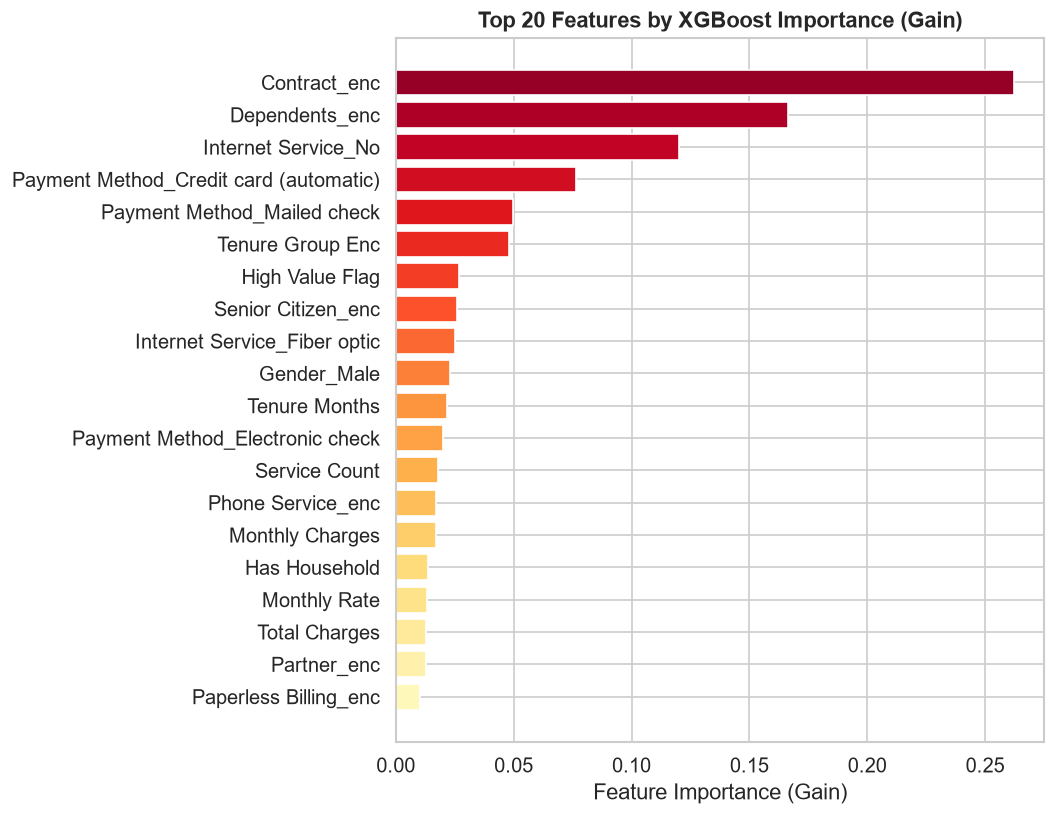

In [13]:
importance_df = (
    pd.DataFrame({
        "Feature"   : X.columns,
        "Importance": xgb.feature_importances_,
    })
    .sort_values("Importance", ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("YlOrRd", len(importance_df))
ax.barh(importance_df["Feature"], importance_df["Importance"],
        color=palette, edgecolor="white")
ax.set_title("Top 20 Features by XGBoost Importance (Gain)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Feature Importance (Gain)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/17_feature_importance.png")
plt.show()


---
## 11. Model Comparison Summary


In [14]:
comparison = pd.DataFrame([
    {
        "Model"         : "Logistic Regression",
        "ROC-AUC (test)": round(lr_results["roc_auc"], 4),
        "ROC-AUC (CV)"  : round(lr_results["cv_auc"],  4),
        "PR-AUC"        : round(lr_results["pr_auc"],  4),
        "F1 (thresh=0.5)": round(lr_results["f1"],     4),
    },
    {
        "Model"         : "XGBoost",
        "ROC-AUC (test)": round(xgb_results["roc_auc"], 4),
        "ROC-AUC (CV)"  : round(xgb_results["cv_auc"],  4),
        "PR-AUC"        : round(xgb_results["pr_auc"],  4),
        "F1 (thresh=0.5)": round(xgb_results["f1"],     4),
    },
])
print(comparison.to_string(index=False))


              Model  ROC-AUC (test)  ROC-AUC (CV)  PR-AUC  F1 (thresh=0.5)
Logistic Regression          0.8363        0.9082  0.6222           0.6212
            XGBoost          0.8476        0.9273  0.6540           0.6205


---
## 12. Save Model Artifacts

We save three artifacts:
- `xgb_model.pkl`: the trained XGBoost classifier
- `feature_columns.json`: the exact feature names in training order (the app needs this)
- `model_metadata.json`: threshold, evaluation metrics, and feature list for reproducibility


In [15]:
# Save model
with open(f"{MODEL_DIR}/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# Save feature column names
feature_cols = X.columns.tolist()
with open(f"{MODEL_DIR}/feature_columns.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

# Save metadata
metadata = {
    "model"              : "XGBoost",
    "optimal_threshold"  : round(float(best_t), 2),
    "roc_auc_test"       : round(float(xgb_results["roc_auc"]), 4),
    "roc_auc_cv"         : round(float(xgb_results["cv_auc"]),  4),
    "pr_auc"             : round(float(xgb_results["pr_auc"]),  4),
    "f1_at_best_threshold": round(float(best_f1), 4),
    "train_rows"         : int(X_train_sm.shape[0]),
    "test_rows"          : int(X_test.shape[0]),
    "n_features"         : int(X.shape[1]),
    "feature_columns"    : feature_cols,
}
with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(f"  {MODEL_DIR}/xgb_model.pkl")
print(f"  {MODEL_DIR}/feature_columns.json")
print(f"  {MODEL_DIR}/model_metadata.json")
print()
print(json.dumps({k: v for k, v in metadata.items() if k != "feature_columns"}, indent=2))


Saved:
  ../outputs/models/xgb_model.pkl
  ../outputs/models/feature_columns.json
  ../outputs/models/model_metadata.json

{
  "model": "XGBoost",
  "optimal_threshold": 0.29,
  "roc_auc_test": 0.8476,
  "roc_auc_cv": 0.9273,
  "pr_auc": 0.654,
  "f1_at_best_threshold": 0.6322,
  "train_rows": 8278,
  "test_rows": 1409,
  "n_features": 22
}


---
## 13. Modeling Summary

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Evaluation metric | ROC-AUC + PR-AUC + F1 | Accuracy is misleading for imbalanced targets |
| Imbalance handling | SMOTE on train only | Prevents synthetic leakage into test set |
| Baseline model | Logistic Regression | Interpretable floor, confirms XGBoost adds value |
| Primary model | XGBoost | Handles mixed types, robust to outliers, top performance |
| Threshold | Tuned to max F1 | Business cost asymmetry favors catching more churners |
| Scale | On LR only | Tree models are scale-invariant |

---
*Next step: `04_shap_explainability.ipynb`. We go beyond feature importance and explain
individual predictions using SHAP values.*
